# IEEE-CIS Fraud Detection — Exploratory Data Analysis

**Dataset:** 590,540 transactions from a real-world e-commerce payment processor (Vesta Corporation), spanning ~6 months. 3.50% positive rate (fraud).

**Goal of this notebook:** Establish empirical foundations for modeling decisions:
- Class imbalance characterization
- Time structure (for train/validation split)
- Missingness patterns (often a fraud signal)
- Feature family inspection (identity, velocity, device)
- Justify PR-AUC over ROC-AUC for evaluation

**This notebook produces no model.** Modeling decisions made here propagate to `src/features.py` and `src/train.py`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

# Paths — relative to project root
DATA_DIR = Path('../data/raw')
TRANSACTION_FILE = DATA_DIR / 'train_transaction.csv'
IDENTITY_FILE = DATA_DIR / 'train_identity.csv'


In [3]:
def reduce_memory_usage(df, verbose=True):
    """
    Downcast numeric columns to smaller dtypes where safe.
    Reduces memory ~60% on IEEE-CIS without changing values.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type == 'object':
            continue  # Leave strings alone
        
        c_min = df[col].min()
        c_max = df[col].max()
        
        if str(col_type).startswith('int'):
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif str(col_type).startswith('float'):
            if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory: {start_mem:.1f} MB → {end_mem:.1f} MB ({(start_mem - end_mem) / start_mem * 100:.1f}% reduction)")
    
    return df

In [4]:
%%time
txn = pd.read_csv(TRANSACTION_FILE)
print(f"Shape: {txn.shape}")
print(f"Memory before optimization: {txn.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
txn = reduce_memory_usage(txn)

Shape: (590540, 394)
Memory before optimization: 2100.7 MB
Memory: 2100.7 MB → 1241.8 MB (40.9% reduction)
CPU times: user 7.49 s, sys: 2.49 s, total: 9.97 s
Wall time: 11 s


In [5]:
%%time
identity = pd.read_csv(IDENTITY_FILE)
print(f"Identity shape: {identity.shape}")
identity = reduce_memory_usage(identity)

# Left join — keep all transactions, identity NaN where missing
df = txn.merge(identity, on='TransactionID', how='left')
print(f"\nMerged shape: {df.shape}")
print(f"Transactions with identity data: {df['id_01'].notna().sum():,} ({df['id_01'].notna().mean()*100:.1f}%)")

# Free up memory — we don't need the originals anymore
del txn, identity
import gc; gc.collect()

Identity shape: (144233, 41)
Memory: 157.6 MB → 144.4 MB (8.4% reduction)

Merged shape: (590540, 434)
Transactions with identity data: 144,233 (24.4%)
CPU times: user 859 ms, sys: 420 ms, total: 1.28 s
Wall time: 1.41 s


0

In [6]:
print(f"Total transactions: {len(df):,}")
print(f"Total fraud cases: {df['isFraud'].sum():,}")
print(f"Fraud positive rate: {df['isFraud'].mean()*100:.2f}%")
print(f"Total columns: {len(df.columns)}")
print(f"Memory in use: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Total transactions: 590,540
Total fraud cases: 20,663
Fraud positive rate: 3.50%
Total columns: 434
Memory in use: 1656.4 MB


## 1. Class imbalance and time structure

**Questions:**
1. Is the 3.50% fraud rate constant across the dataset's time window, or does it drift?
2. What is the time span of the data, and where should we split for training and validation?

Random splits are inappropriate for fraud data — fraud patterns evolve over time, and a random split leaks future information into the training set. Production fraud systems are always evaluated on data from after the training period. We replicate that constraint here.

In [7]:
# TransactionDT is seconds since some reference point
print(f"TransactionDT range: {df['TransactionDT'].min():,} to {df['TransactionDT'].max():,}")
print(f"Span in days: {(df['TransactionDT'].max() - df['TransactionDT'].min()) / 86400:.1f}")
print(f"Span in weeks: {(df['TransactionDT'].max() - df['TransactionDT'].min()) / 86400 / 7:.1f}")

# Convert to days since dataset start for readable analysis
df['day'] = ((df['TransactionDT'] - df['TransactionDT'].min()) / 86400).astype(np.int16)
print(f"\nDay range: {df['day'].min()} to {df['day'].max()}")
print(f"Total days: {df['day'].nunique()}")

TransactionDT range: 86,400 to 15,811,131
Span in days: 182.0
Span in weeks: 26.0

Day range: 0 to 181
Total days: 182


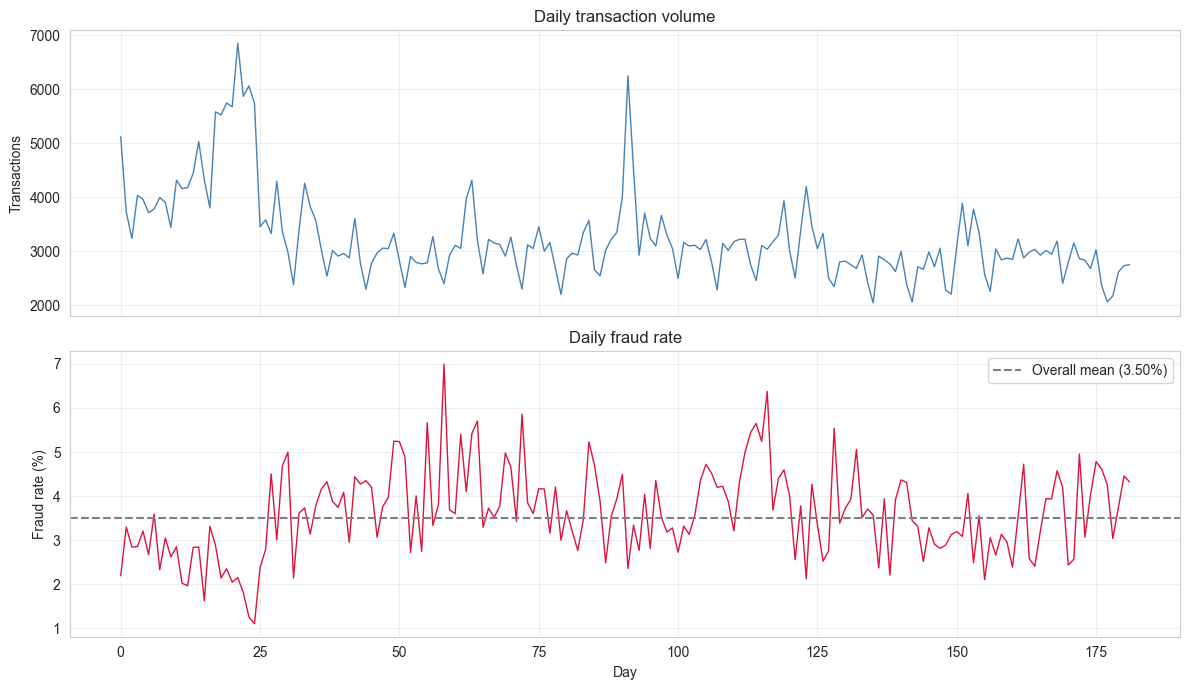

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Daily transaction volume
daily_volume = df.groupby('day').size()
axes[0].plot(daily_volume.index, daily_volume.values, color='steelblue', linewidth=1)
axes[0].set_ylabel('Transactions')
axes[0].set_title('Daily transaction volume')
axes[0].grid(True, alpha=0.3)

# Daily fraud rate
daily_fraud_rate = df.groupby('day')['isFraud'].mean() * 100
axes[1].plot(daily_fraud_rate.index, daily_fraud_rate.values, color='crimson', linewidth=1)
axes[1].axhline(df['isFraud'].mean() * 100, color='gray', linestyle='--', label=f'Overall mean ({df["isFraud"].mean()*100:.2f}%)')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud rate (%)')
axes[1].set_title('Daily fraud rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/01_volume_and_fraud_rate.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# Split data into 4 quartiles by time and compare fraud rates
df['time_quartile'] = pd.qcut(df['day'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

quartile_stats = df.groupby('time_quartile').agg(
    transactions=('isFraud', 'size'),
    fraud_count=('isFraud', 'sum'),
    fraud_rate=('isFraud', 'mean')
).round(4)
quartile_stats['fraud_rate_pct'] = (quartile_stats['fraud_rate'] * 100).round(2)
quartile_stats['day_min'] = df.groupby('time_quartile')['day'].min().values
quartile_stats['day_max'] = df.groupby('time_quartile')['day'].max().values

print("Fraud rate by time quartile:")
print(quartile_stats[['day_min', 'day_max', 'transactions', 'fraud_count', 'fraud_rate_pct']])

Fraud rate by time quartile:
               day_min  day_max  transactions  fraud_count  fraud_rate_pct
time_quartile                                                             
Q1                   0       34        151205         4003            2.65
Q2                  35       83        146338         5967            4.08
Q3                  84      129        147630         5660            3.83
Q4                 130      181        145367         5033            3.46


### Time-based split

We split the data into three contiguous time-ordered segments:

| Split | Day range | Purpose |
|-------|-----------|---------|
| Train | 0 – 121 (first 4 months) | Model fitting |
| Validation | 122 – 152 (next 1 month) | Threshold tuning, early stopping |
| Test | 153 – 182 (final ~1 month) | Held-out evaluation |

**Rationale:**
- A random split would let the model see future patterns during training, inflating performance metrics in a way that doesn't replicate production conditions.
- Production fraud systems are always trained on past data and evaluated on future data. Our split mirrors that.
- The 4/1/1 month proportions reflect the standard 70/15/15 split for this dataset, while preserving temporal order.
- The test set being a full month (not just a few days) lets us evaluate stability — fraud rate varies day-to-day, so a too-small test window adds noise.

In [10]:
# Define split boundaries
TRAIN_END_DAY = 121
VAL_END_DAY = 152

train_mask = df['day'] <= TRAIN_END_DAY
val_mask = (df['day'] > TRAIN_END_DAY) & (df['day'] <= VAL_END_DAY)
test_mask = df['day'] > VAL_END_DAY

print(f"Train:      {train_mask.sum():>7,} transactions ({train_mask.mean()*100:.1f}%) — fraud rate {df.loc[train_mask, 'isFraud'].mean()*100:.2f}%")
print(f"Validation: {val_mask.sum():>7,} transactions ({val_mask.mean()*100:.1f}%) — fraud rate {df.loc[val_mask, 'isFraud'].mean()*100:.2f}%")
print(f"Test:       {test_mask.sum():>7,} transactions ({test_mask.mean()*100:.1f}%) — fraud rate {df.loc[test_mask, 'isFraud'].mean()*100:.2f}%")

# Sanity — splits should be disjoint and cover everything
assert train_mask.sum() + val_mask.sum() + test_mask.sum() == len(df)
print("\n✓ Splits are disjoint and complete")

Train:      420,066 transactions (71.1%) — fraud rate 3.52%
Validation:  88,149 transactions (14.9%) — fraud rate 3.41%
Test:        82,325 transactions (13.9%) — fraud rate 3.48%

✓ Splits are disjoint and complete


### Observations from the time-structure plots

- **Launch effect (days 0–25):** Higher volume, lower fraud rate. Likely early-adopter cohort before fraud discovery. Modeling implication: don't overweight this period, or train fraud features may not transfer.
- **Active fraud period (days 25–130):** Volatile fraud rates 4–6%, peaks near 7%. This is the regime fraud detection has to handle.
- **Stabilization (days 130+):** Lower, more stable fraud rates ~3.5%. Our test set sits in this regime, which is the realistic production case (newer than training data, with whatever drift has accumulated).

**Implication for evaluation:** train fraud rate (3.52%) > test fraud rate (3.48%). The model will be evaluated on a slightly easier distribution than it trained on, but threshold-tuning on validation (3.41%) gives us a reasonable proxy for test conditions.

### Why PR-AUC, not ROC-AUC

With 3.50% positive rate, ROC-AUC is misleading. Here's why:

ROC curves plot TPR vs FPR. When negatives outnumber positives ~28:1, even a substantial change in absolute false positives barely moves the FPR. A model that flags 5,700 false positives looks identical on a ROC curve to one that flags 11,400 — both correspond to ~1% and ~2% FPR — yet for fraud operations, that doubling of review queue volume is a major operational difference.

PR (Precision-Recall) curves directly reflect the false-positive cost: precision is `TP / (TP + FP)`, so doubling FP halves precision. PR-AUC also has a sensible baseline: a random classifier achieves PR-AUC equal to the positive rate (~0.035 here), making improvement easy to interpret.

**We will report both, but PR-AUC is our primary metric.**

In [11]:
# Illustrate the difference: a "random" model's expected metrics
n_pos = df['isFraud'].sum()
n_neg = len(df) - n_pos
positive_rate = n_pos / len(df)

print(f"Random classifier baselines:")
print(f"  ROC-AUC: 0.500 (always)")
print(f"  PR-AUC:  {positive_rate:.4f} (= positive rate)")
print(f"\nA model claiming ROC-AUC of 0.85 sounds great.")
print(f"The same model might have PR-AUC of 0.20 — only 5x better than random,")
print(f"meaning it still drowns in false positives.")

Random classifier baselines:
  ROC-AUC: 0.500 (always)
  PR-AUC:  0.0350 (= positive rate)

A model claiming ROC-AUC of 0.85 sounds great.
The same model might have PR-AUC of 0.20 — only 5x better than random,
meaning it still drowns in false positives.


## 2. Missingness analysis

IEEE-CIS has heavy missingness, especially in the identity columns (id_01–38, DeviceType, DeviceInfo) which only exist for ~24% of transactions. We need to:

1. Quantify column-level missingness.
2. Test whether *the act of being missing* correlates with fraud (often does).
3. Decide which columns to drop, impute, or use missingness flags for.

In [12]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

# Bucketize
buckets = pd.cut(
    missing_pct,
    bins=[-0.01, 0, 25, 50, 75, 90, 100],
    labels=['0% (complete)', '0-25%', '25-50%', '50-75%', '75-90%', '90-100%']
)

print("Columns by missingness bucket:")
print(buckets.value_counts().sort_index().to_string())

print(f"\nFully complete columns: {(missing_pct == 0).sum()}")
print(f"Columns >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns >90% missing: {(missing_pct > 90).sum()}")

Columns by missingness bucket:
0% (complete)     22
0-25%            162
25-50%            38
50-75%             6
75-90%           196
90-100%           12

Fully complete columns: 22
Columns >50% missing: 214
Columns >90% missing: 12


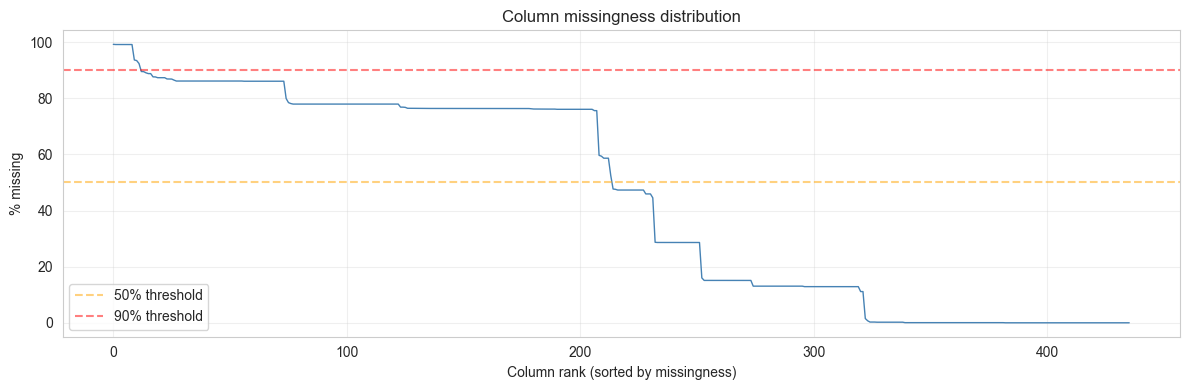

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
missing_pct.values  # already sorted descending
ax.plot(range(len(missing_pct)), missing_pct.values, color='steelblue', linewidth=1)
ax.axhline(50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
ax.axhline(90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
ax.set_xlabel('Column rank (sorted by missingness)')
ax.set_ylabel('% missing')
ax.set_title('Column missingness distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/02_missingness_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# For each column, compute fraud rate when present vs missing
columns_to_test = [c for c in df.columns if c not in ['TransactionID', 'isFraud', 'day', 'time_quartile']]

missingness_signal = []
for col in columns_to_test:
    is_missing = df[col].isna()
    if is_missing.sum() == 0 or is_missing.sum() == len(df):
        continue  # Skip fully-present or fully-missing columns
    
    fraud_when_missing = df.loc[is_missing, 'isFraud'].mean()
    fraud_when_present = df.loc[~is_missing, 'isFraud'].mean()
    
    missingness_signal.append({
        'column': col,
        'pct_missing': is_missing.mean() * 100,
        'fraud_rate_when_missing': fraud_when_missing * 100,
        'fraud_rate_when_present': fraud_when_present * 100,
        'fraud_rate_lift': (fraud_when_missing - fraud_when_present) * 100  # positive = missing is more fraud-y
    })

signal_df = pd.DataFrame(missingness_signal).sort_values('fraud_rate_lift', ascending=False)

print("Top 15 columns where MISSING value indicates HIGHER fraud rate:")
print(signal_df.head(15).round(2).to_string(index=False))

print("\nTop 15 columns where MISSING value indicates LOWER fraud rate:")
print(signal_df.tail(15).round(2).to_string(index=False))

Top 15 columns where MISSING value indicates HIGHER fraud rate:
column  pct_missing  fraud_rate_when_missing  fraud_rate_when_present  fraud_rate_lift
  V280          0.0                    16.67                      3.5            13.17
  V309          0.0                    16.67                      3.5            13.17
  V320          0.0                    16.67                      3.5            13.17
  V304          0.0                    16.67                      3.5            13.17
  V305          0.0                    16.67                      3.5            13.17
  V306          0.0                    16.67                      3.5            13.17
  V307          0.0                    16.67                      3.5            13.17
  V308          0.0                    16.67                      3.5            13.17
  V319          0.0                    16.67                      3.5            13.17
  V299          0.0                    16.67                      

In [15]:
# Re-run with minimum sample size threshold
# Lift estimates are unreliable when "missing" group has very few rows
MIN_MISSING_ROWS = 1000

missingness_signal_filtered = []
for col in columns_to_test:
    is_missing = df[col].isna()
    n_missing = is_missing.sum()
    n_present = len(df) - n_missing
    
    # Require both groups to have enough samples for a reliable estimate
    if n_missing < MIN_MISSING_ROWS or n_present < MIN_MISSING_ROWS:
        continue
    
    fraud_when_missing = df.loc[is_missing, 'isFraud'].mean()
    fraud_when_present = df.loc[~is_missing, 'isFraud'].mean()
    
    missingness_signal_filtered.append({
        'column': col,
        'pct_missing': is_missing.mean() * 100,
        'n_missing': n_missing,
        'fraud_rate_when_missing': fraud_when_missing * 100,
        'fraud_rate_when_present': fraud_when_present * 100,
        'fraud_rate_lift': (fraud_when_missing - fraud_when_present) * 100
    })

signal_df_clean = pd.DataFrame(missingness_signal_filtered).sort_values('fraud_rate_lift', ascending=False)

print("Top 15 columns where MISSING indicates HIGHER fraud (min 1000 samples per group):")
print(signal_df_clean.head(15).round(2).to_string(index=False))

print(f"\nTotal columns analyzed: {len(signal_df_clean)} (filtered from {len(missingness_signal)} for sample size)")

Top 15 columns where MISSING indicates HIGHER fraud (min 1000 samples per group):
column  pct_missing  n_missing  fraud_rate_when_missing  fraud_rate_when_present  fraud_rate_lift
 addr1        11.13      65706                    11.78                     2.46             9.32
 addr2        11.13      65706                    11.78                     2.46             9.32
    M6        28.68     169360                     7.07                     2.06             5.00
    M1        45.91     271100                     5.28                     1.99             3.30
    M2        45.91     271100                     5.28                     1.99             3.30
    M3        45.91     271100                     5.28                     1.99             3.30
    V9        47.29     279287                     5.21                     1.96             3.25
    V5        47.29     279287                     5.21                     1.96             3.25
   V11        47.29     279287      

**Note on filtering:** the initial top-15 lift table was dominated by columns with <100 NaN rows out of 590K. With such tiny denominators, a single fraud case in the "missing" group produces a 16.67% rate that's statistical noise, not signal. We re-run with a minimum 1000-row threshold per group, which surfaces only patterns supported by enough data to be reliable.

In [16]:
# Email domain columns — for identity consistency features
print("=== Email domain columns ===")
for col in ['P_emaildomain', 'R_emaildomain']:
    n_missing = df[col].isna().sum()
    n_unique = df[col].nunique()
    print(f"{col}: {n_missing:,} missing ({n_missing/len(df)*100:.1f}%), {n_unique} unique domains")

print("\nTop 10 P_emaildomain values:")
print(df['P_emaildomain'].value_counts().head(10).to_string())

print("\nTop 10 R_emaildomain values:")
print(df['R_emaildomain'].value_counts().head(10).to_string())

=== Email domain columns ===
P_emaildomain: 94,456 missing (16.0%), 59 unique domains
R_emaildomain: 453,249 missing (76.8%), 60 unique domains

Top 10 P_emaildomain values:
P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033

Top 10 R_emaildomain values:
R_emaildomain
gmail.com        57147
hotmail.com      27509
anonymous.com    20529
yahoo.com        11842
aol.com           3701
outlook.com       2507
comcast.net       1812
yahoo.com.mx      1508
icloud.com        1398
msn.com            852


In [17]:
# Card columns — for velocity features (we'll group by these)
print("=== Card columns ===")
for col in ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']:
    n_missing = df[col].isna().sum()
    n_unique = df[col].nunique()
    print(f"{col}: {n_missing:,} missing ({n_missing/len(df)*100:.1f}%), {n_unique} unique values")

=== Card columns ===
card1: 0 missing (0.0%), 13553 unique values
card2: 8,933 missing (1.5%), 500 unique values
card3: 1,565 missing (0.3%), 114 unique values
card4: 1,577 missing (0.3%), 4 unique values
card5: 4,259 missing (0.7%), 119 unique values
card6: 1,571 missing (0.3%), 4 unique values


In [18]:
# Device columns — for device-linkage features
print("=== Device columns ===")
for col in ['DeviceType', 'DeviceInfo', 'id_30', 'id_31']:
    if col in df.columns:
        n_missing = df[col].isna().sum()
        n_unique = df[col].nunique()
        print(f"{col}: {n_missing:,} missing ({n_missing/len(df)*100:.1f}%), {n_unique} unique values")
        
print("\nTop 10 DeviceType values:")
print(df['DeviceType'].value_counts().head(10).to_string())

print("\nTop 10 DeviceInfo values (truncated):")
print(df['DeviceInfo'].value_counts().head(10).to_string())

=== Device columns ===
DeviceType: 449,730 missing (76.2%), 2 unique values
DeviceInfo: 471,874 missing (79.9%), 1786 unique values
id_30: 512,975 missing (86.9%), 75 unique values
id_31: 450,258 missing (76.2%), 130 unique values

Top 10 DeviceType values:
DeviceType
desktop    85165
mobile     55645

Top 10 DeviceInfo values (truncated):
DeviceInfo
Windows                  47722
iOS Device               19782
MacOS                    12573
Trident/7.0               7440
rv:11.0                   1901
rv:57.0                    962
SM-J700M Build/MMB29K      549
SM-G610M Build/MMB29K      461
SM-G531H Build/LMY48B      410
rv:59.0                    362


In [19]:
top_p_domains = df['P_emaildomain'].value_counts().head(10).index

fraud_by_domain = df[df['P_emaildomain'].isin(top_p_domains)].groupby('P_emaildomain').agg(
    transactions=('isFraud', 'size'),
    fraud_rate=('isFraud', lambda x: x.mean() * 100)
).round(2).sort_values('fraud_rate', ascending=False)

print("Fraud rate by P_emaildomain (top 10 by volume):")
print(fraud_by_domain.to_string())

Fraud rate by P_emaildomain (top 10 by volume):
               transactions  fraud_rate
P_emaildomain                          
outlook.com            5096        9.46
hotmail.com           45250        5.30
gmail.com            228355        4.35
icloud.com             6267        3.14
comcast.net            7888        3.12
anonymous.com         36998        2.32
yahoo.com            100934        2.28
msn.com                4092        2.20
aol.com               28289        2.18
att.net                4033        0.74


### Modeling decisions from EDA

**Column-level handling:**
1. Drop columns >90% missing (12 columns).
2. Keep moderately-missing columns as-is — XGBoost/LightGBM handle missingness natively.
3. Add `_isna` flags for high-signal columns: `addr1_isna` (9.3pp lift), `M6_isna` (5.0pp), `M1_isna` (3.3pp, group representative), `V4_isna` (3.3pp, group representative).

**Identity-consistency features:**
4. `email_domain_match` (P_emaildomain == R_emaildomain, NaN-aware)
5. `has_recipient_email` (proxy for transaction type)
6. `email_is_freemail` (P in known freemail providers)
7. `email_domain_fraud_rate` (training-data only, to prevent leakage)

**Transaction-level features:**
8. `log_amount` — log1p of TransactionAmt (heavy right-tail distribution)
9. `amount_decimal_part` — TransactionAmt − floor(TransactionAmt) (round-number patterns)
10. Hour-of-day, day-of-week, weekend flag from TransactionDT

**Velocity features:**
11. card1-grouped rolling counts and amount sums over 24h and 7d windows
12. addr1-grouped rolling counts over 24h window (where present)

**Card behavioral baselines:**
13. Mean and std of TransactionAmt per card1 (training data only)
14. Z-score of current amount vs card1 baseline

**Device-linkage features:**
15. DeviceInfo frequency count (how many transactions share this device)
16. id_31 (browser) frequency count
17. DeviceInfo bucketed (top 50 + "Other")

**Validation guardrails:**
18. No feature uses test or validation data for fitting.
19. All engineered features are deterministic given the input row at scoring time.

In [20]:
# Drop EDA-only helper columns
df = df.drop(columns=['day', 'time_quartile'])
print(f"Final shape: {df.shape}")

Final shape: (590540, 434)


In [21]:
%%time
output_path = Path('../data/processed/merged.parquet')
df.to_parquet(output_path, engine='pyarrow', compression='snappy', index=False)

file_size_mb = output_path.stat().st_size / 1024**2
print(f"\nSaved to: {output_path}")
print(f"File size: {file_size_mb:.1f} MB")
print(f"Shape: {df.shape}")


Saved to: ../data/processed/merged.parquet
File size: 76.6 MB
Shape: (590540, 434)
CPU times: user 3.97 s, sys: 116 ms, total: 4.09 s
Wall time: 4.4 s


In [23]:
%%time
# Reload and verify
df_check = pd.read_parquet(output_path)

assert df_check.shape == df.shape, "Shape mismatch on reload"
assert df_check['isFraud'].mean() == df['isFraud'].mean(), "Fraud rate mismatch"

# Check critical dtypes preserved (not memory bytes — those can shift across save/load)
assert df_check['TransactionAmt'].dtype == df['TransactionAmt'].dtype, "TransactionAmt dtype changed"
assert df_check['isFraud'].dtype == df['isFraud'].dtype, "isFraud dtype changed"
assert df_check['card1'].dtype == df['card1'].dtype, "card1 dtype changed"

print(f"✓ Reload verified: {df_check.shape}, fraud rate {df_check['isFraud'].mean()*100:.2f}%")
print(f"✓ Critical dtypes preserved")
print(f"  Memory before save: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"  Memory after reload: {df_check.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

del df_check

✓ Reload verified: (590540, 434), fraud rate 3.50%
✓ Critical dtypes preserved
  Memory before save: 1656.4 MB
  Memory after reload: 1569.9 MB
CPU times: user 4.05 s, sys: 715 ms, total: 4.77 s
Wall time: 2.77 s


## Summary

**Dataset:** 590,540 transactions, 3.50% fraud rate, 182 days

**Time-based split:**
- Train: days 0–121 (420,066 transactions, 3.52% fraud)
- Validation: days 122–152 (88,149 transactions, 3.41% fraud)
- Test: days 153–181 (82,325 transactions, 3.48% fraud)

**Key empirical findings:**
1. Fraud rate is non-stationary across the dataset — Q2 has 1.5x the fraud rate of Q1.
2. Missingness is a stronger signal than most feature values: missing `addr1` corresponds to 4.8x fraud rate (11.78% vs 2.46%).
3. Email domains vary 12x in fraud rate across major providers (outlook.com 9.46% vs att.net 0.74%).
4. Identity columns are present for only 24.4% of transactions; this absence is itself informative.

**Primary metric:** PR-AUC, with capture rate at fixed FPR (1%, 2%) as operational metric.

**Output:** `data/processed/merged.parquet` (memory-optimized, dtypes preserved). Used as input to `src/features.py`.